In [60]:
from typing_extensions import TypedDict

class MyState(TypedDict):
    message: str
    a: str
    b: str


In [61]:
def node_1(state: MyState) -> MyState:

    print(f"node_1")

    return {"a":  "hello " + state["message"] }

def node_2(state: MyState) -> MyState:

    print(f"node_2")

    return {"b":  "hello " + state["a"] }

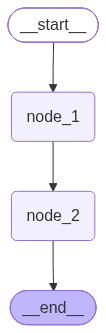

In [62]:
from langgraph.graph import StateGraph

workflow = StateGraph(MyState)
workflow.add_node("node_1", node_1)
workflow.add_node("node_2", node_2)

workflow.add_edge("node_1", "node_2")

workflow.set_entry_point("node_1")
workflow.set_finish_point("node_2")

graph= workflow.compile()
graph


In [63]:
graph.invoke({"message": "world"})

node_1
node_2


{'message': 'world', 'a': 'hello world', 'b': 'hello hello world'}

In [64]:
for data in graph.stream({"message": "world"}):
    print(data)

node_1
{'node_1': {'a': 'hello world'}}
node_2
{'node_2': {'b': 'hello hello world'}}


In [65]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

In [69]:
from typing_extensions import Annotated
import operator

class MyState(TypedDict):
    messages: Annotated[list, operator.add]

In [70]:
from langchain_core.messages import HumanMessage

def func_1(state: MyState) -> MyState:

    model_response = llm.invoke(state["messages"])

    return {"messages": [model_response]}

def func_2(state: MyState) -> MyState:

    return state


workflow = StateGraph(MyState)
workflow.add_node("func_1", func_1)
workflow.add_node("func_2", func_2)
workflow.set_entry_point("func_1")
workflow.add_edge("func_1", "func_2")
workflow.set_finish_point("func_2")

graph= workflow.compile()

graph.invoke({"messages": [HumanMessage(content="My Name is siva")]})

{'messages': [HumanMessage(content='My Name is siva', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Nice to meet you, Siva! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 12, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a8bfe22efe', 'id': 'chatcmpl-EU37PKItOc7GWbGZxEZXQjnEJ0GXu', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0f5d1-60aa-7f11-821e-df452ce272d3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 15, 'total_tokens': 

In [71]:
import operator

l1 = [1,2,3]
l2 = [2,3,6]

operator.add(l1,l2)

[1, 2, 3, 2, 3, 6]

In [72]:
from langgraph.graph import add_messages
from langchain_core.messages import HumanMessage,AIMessage

l1=[HumanMessage(content="My Name is siva" , id="1"), AIMessage(content="Hello, Nice to meet you", id="2")]
l2=[HumanMessage(content="My Name is Prasad", id="1"), AIMessage(content="Hello, Nice to meet you", id="4")]

add_messages(l1,l2)

[HumanMessage(content='My Name is Prasad', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='Hello, Nice to meet you', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[]),
 AIMessage(content='Hello, Nice to meet you', additional_kwargs={}, response_metadata={}, id='4', tool_calls=[], invalid_tool_calls=[])]

In [73]:
l1= [HumanMessage(content="My Name is siva" , id="1"), AIMessage(content="Hello, Nice to meet you", id="2")]
l1.append(HumanMessage(content="My Name is Prasad", id="3"))
l1.append(AIMessage(content="Hello, Nice to meet you", id="4"))

l1

[HumanMessage(content='My Name is siva', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='Hello, Nice to meet you', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='My Name is Prasad', additional_kwargs={}, response_metadata={}, id='3'),
 AIMessage(content='Hello, Nice to meet you', additional_kwargs={}, response_metadata={}, id='4', tool_calls=[], invalid_tool_calls=[])]

In [74]:
from langchain_core.messages import RemoveMessage

messages_tobe_removed = [RemoveMessage(id="1"), RemoveMessage(id="4")]

add_messages(l1,messages_tobe_removed)

[AIMessage(content='Hello, Nice to meet you', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='My Name is Prasad', additional_kwargs={}, response_metadata={}, id='3')]

In [75]:
from typing_extensions import Annotated
import operator

class MyState(TypedDict):
    messages: Annotated[list, add_messages]

    

In [76]:
from langchain_core.messages import HumanMessage

def func_1(state: MyState) -> MyState:

    model_response = llm.invoke(state["messages"])

    return {"messages": [model_response]}

def func_2(state: MyState) -> MyState:

    return state


workflow = StateGraph(MyState)
workflow.add_node("func_1", func_1)
workflow.add_node("func_2", func_2)
workflow.set_entry_point("func_1")
workflow.add_edge("func_1", "func_2")
workflow.set_finish_point("func_2")

graph= workflow.compile()

graph.invoke({"messages": [HumanMessage(content="My Name is siva")]})

{'messages': [HumanMessage(content='My Name is siva', additional_kwargs={}, response_metadata={}, id='ca656518-c2d0-4b45-8578-b854b8ea2734'),
  AIMessage(content='Hello, Siva! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 12, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a8bfe22efe', 'id': 'chatcmpl-EU39iEkJ9PSUVaApLBQcXqObKvmtq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0f5d3-8d82-7041-a3be-21a05b810c02-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'outp

In [ ]:
from langchain_community.utilities import OpenWeatherMapAPIWrapper
import os
weather = OpenWeatherMapAPIWrapper()
weather.run("Mumbai")

In [77]:
class MyState(TypedDict):
    query: str
    city: str
    weather: str
    response: str

class InputState(TypedDict):
    query: str

class OutputState(TypedDict):
    response: str


def function_1(state: MyState) -> MyState:
    prompt = "Your task is to provide only city name based on the query. " \
             "Just return the city name without any additional text. Following is the query: " + state['query']

    response = llm.invoke(prompt)
    
    return {"city": response.content}

def function_2(state):
    response = weather.run(state['city'])
    return {"weather": response}

def function_3(state):
    agent2_query = """Your task is to provide info concisely based on the
             user query and the available information from the internet.
            Following is the user query: """ + state['query'] + " Available information: " + state['weather']
    response = llm.invoke(agent2_query)
    return {"response": response.content}



In [79]:
workflow = StateGraph(MyState, input_schema=InputState, output_schema=OutputState)
workflow.add_node("function_1", function_1)
workflow.add_node("function_2", function_2)
workflow.add_node("function_3", function_3)

workflow.set_entry_point("function_1")
workflow.add_edge("function_1", "function_2")
workflow.add_edge("function_2", "function_3")

workflow.set_finish_point("function_3")
graph= workflow.compile()

graph.invoke({"query": "What is the wind speed  in Mumbai?"})

{'response': 'The current wind speed in Mumbai is 1.69 m/s, coming from the direction of 94°.'}

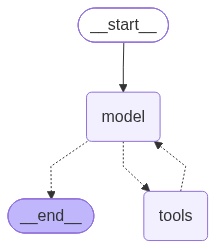

In [80]:
from langchain.agents import create_agent
from langchain_tavily import TavilySearch

agent = create_agent(model=llm,tools=[TavilySearch()])
agent


In [83]:
llm.invoke("who won t20 world cup 2026")
llm_withtools=llm.bind_tools([TavilySearch()])
result= llm_withtools.invoke("who won t20 world cup 2026")
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 1196, 'total_tokens': 1224, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d3ba5542b', 'id': 'chatcmpl-EU3JAaZKf9eFHyu5zWQjVlbRY4bNn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0f5dc-82a6-70d1-b497-40f2a32eff93-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'T20 World Cup 2026 winner', 'search_depth': 'basic'}, 'id': 'call_INtUu7BiduJq6pe9h1I20piy', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1196, 'output_tokens':

In [84]:
result.tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'T20 World Cup 2026 winner', 'search_depth': 'basic'},
  'id': 'call_INtUu7BiduJq6pe9h1I20piy',
  'type': 'tool_call'}]

In [91]:
from langgraph.prebuilt import ToolNode
from langgraph.graph import START, END
from langgraph.checkpoint.memory import InMemorySaver

class MyState(TypedDict):
    messages: Annotated[list, add_messages]


def create_myagent(model,tools,checkpointer):

    def where_to_go(state: MyState) -> str:
        last_msg= state["messages"][-1]
        if last_msg.tool_calls:
            return "my_tool_node"
        else:
            return "my_end"


    def model_node(state: MyState) -> MyState:
        model_withtools=model.bind_tools(tools)
        model_response=model_withtools.invoke(state["messages"])

        return {"messages": [model_response]}
    
    workflow = StateGraph(MyState)
    workflow.add_node("model_node", model_node)
    workflow.set_entry_point("model_node")
    workflow.add_node("tool_node", ToolNode(tools))

    workflow.add_conditional_edges("model_node", where_to_go , {
        "my_tool_node": "tool_node",
        "my_end": END
    })

    workflow.add_edge("tool_node", "model_node")
   

    return workflow.compile(checkpointer=checkpointer)

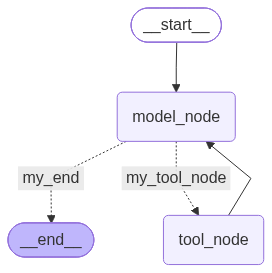

In [92]:
agent= create_myagent(model= llm, tools= [TavilySearch()],checkpointer=InMemorySaver())
agent

In [93]:
config = {"configurable": {"thread_id": "123"}}

agent.invoke({"messages": [HumanMessage(content="who won t20 world cup 2026")]}, config=config)

{'messages': [HumanMessage(content='who won t20 world cup 2026', additional_kwargs={}, response_metadata={}, id='8ada33c2-a7f8-47ee-a907-af7cac19a13d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1196, 'total_tokens': 1223, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d3ba5542b', 'id': 'chatcmpl-EU3YCtoEnLkofyHGG0hzP2MTr0HeC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0f5ea-b3f3-7d50-9ec2-d55962fe9b4a-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'T20 World Cup 2026 winner', 'topic': '

In [94]:
agent.invoke({"messages": [HumanMessage(content="where was that last match played")]}, config=config)

{'messages': [HumanMessage(content='who won t20 world cup 2026', additional_kwargs={}, response_metadata={}, id='8ada33c2-a7f8-47ee-a907-af7cac19a13d'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 1196, 'total_tokens': 1223, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5d3ba5542b', 'id': 'chatcmpl-EU3YCtoEnLkofyHGG0hzP2MTr0HeC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0f5ea-b3f3-7d50-9ec2-d55962fe9b4a-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'T20 World Cup 2026 winner', 'topic': '